# Stacking Ensemble Demo on Noisy Synthetic Data

**Klasifikatori:**
1. **Naive Bayes (NB)** - pretpostavlja da značajke uglavnom nisu korelirane
2. **Logistic Regression (LR)** - linearni klasifikator
3. **Decision Tree (DT)** - veća dubina, bolja točnost na trainsetu ali uz mogućnost overfittinga

**meta-learner** - LR

**Synth dataset docs**: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html



## 1. Učitavanje dataseta

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, StratifiedKFold
import seaborn as sns
import itertools

from FE_demo2 import features


In [2]:
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                           n_redundant=3, flip_y=0.2, class_sep=0.7, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


df = pd.DataFrame(X, columns=[f"F{i}" for i in range(X.shape[1])])
df["label"] = y

#sns.pairplot(df, hue="label", corner=True, palette="coolwarm")
#plt.suptitle("Pairwise Feature Scatterplots", y=1.02)
#plt.show()

## 2. Usporedba: pojedinačni modeli vs STACKING

In [3]:
def evaluate_model_cv(name, model, X, y):
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    print(f"{name:20s} Mean Acc: {scores.mean():.3f} | Std: {scores.std():.3f}")
    return scores

In [4]:
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42)
}

estimators = [(name.lower().replace(' ', '_'), model) for name, model in models.items()]
final_estimator = LogisticRegression()
stack = StackingClassifier(estimators=estimators, final_estimator=final_estimator, cv=5)
stack




StackingClassifier(cv=5,
                   estimators=[('naive_bayes', GaussianNB()),
                               ('logistic_regression', LogisticRegression()),
                               ('decision_tree',
                                DecisionTreeClassifier(max_depth=5,
                                                       random_state=42))],
                   final_estimator=LogisticRegression())

Classification Report - Naive Bayes:

              precision    recall  f1-score   support

     Class 0       0.71      0.73      0.72       149
     Class 1       0.73      0.70      0.71       151

    accuracy                           0.72       300
   macro avg       0.72      0.72      0.72       300
weighted avg       0.72      0.72      0.72       300



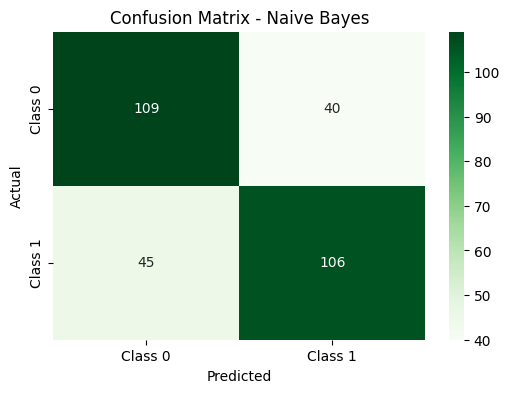

Classification Report - Logistic Regression:

              precision    recall  f1-score   support

     Class 0       0.71      0.69      0.70       149
     Class 1       0.70      0.72      0.71       151

    accuracy                           0.71       300
   macro avg       0.71      0.71      0.71       300
weighted avg       0.71      0.71      0.71       300



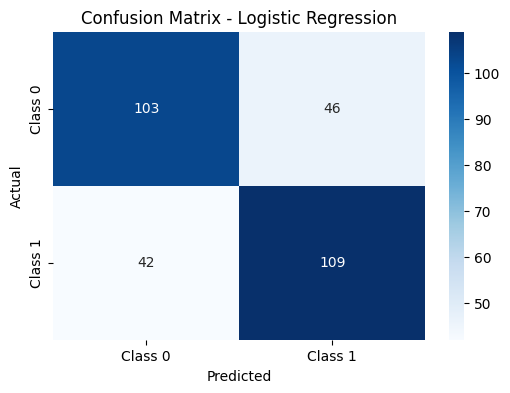

Classification Report - Decision Tree:

              precision    recall  f1-score   support

     Class 0       0.69      0.73      0.71       149
     Class 1       0.72      0.68      0.70       151

    accuracy                           0.70       300
   macro avg       0.70      0.70      0.70       300
weighted avg       0.70      0.70      0.70       300



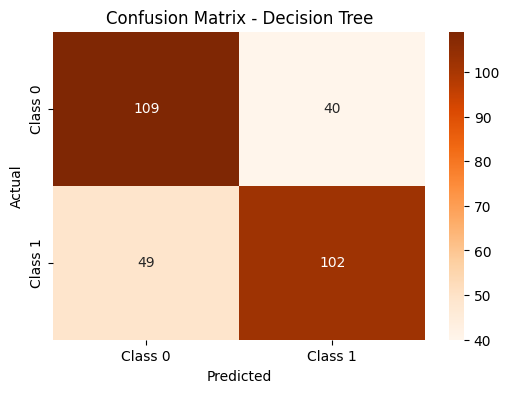

Classification Report - Stacking:

              precision    recall  f1-score   support

     Class 0       0.75      0.74      0.74       149
     Class 1       0.75      0.75      0.75       151

    accuracy                           0.75       300
   macro avg       0.75      0.75      0.75       300
weighted avg       0.75      0.75      0.75       300



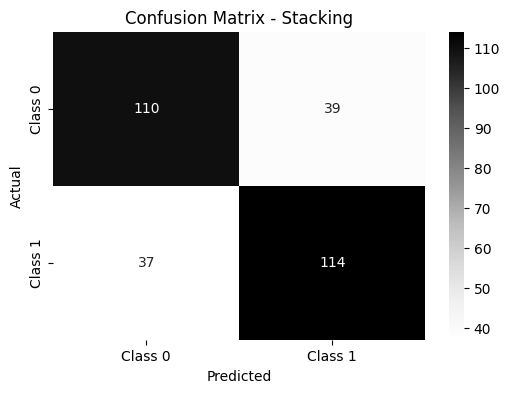

In [5]:
# Evaluacija 70-30
class_names = [f"Class {i}" for i in np.unique(y)]

# re-fit & predict
color_maps = ["Greens", "Blues", "Oranges"]

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Classification Report - {name}:\n")
    print(classification_report(y_test, y_pred, target_names=class_names))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    cmap = color_maps[i % len(color_maps)]
    sns.heatmap(cm, annot=True, cmap=cmap, xticklabels=class_names, yticklabels=class_names, fmt='d')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


stack.fit(X_train, y_train)
y_pred = stack.predict(X_test)

print("Classification Report - Stacking:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Greys", xticklabels=class_names, yticklabels=class_names, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Stacking")
plt.show()

Naive Bayes          Mean Acc: 0.701 | Std: 0.013
Logistic Regression  Mean Acc: 0.708 | Std: 0.035
Decision Tree        Mean Acc: 0.679 | Std: 0.023
Stacking             Mean Acc: 0.733 | Std: 0.014


C:\Users\Nikolina\AppData\Local\Temp\ipykernel_24996\3409864177.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_results.values(), labels=cv_results.keys(), showmeans=True)


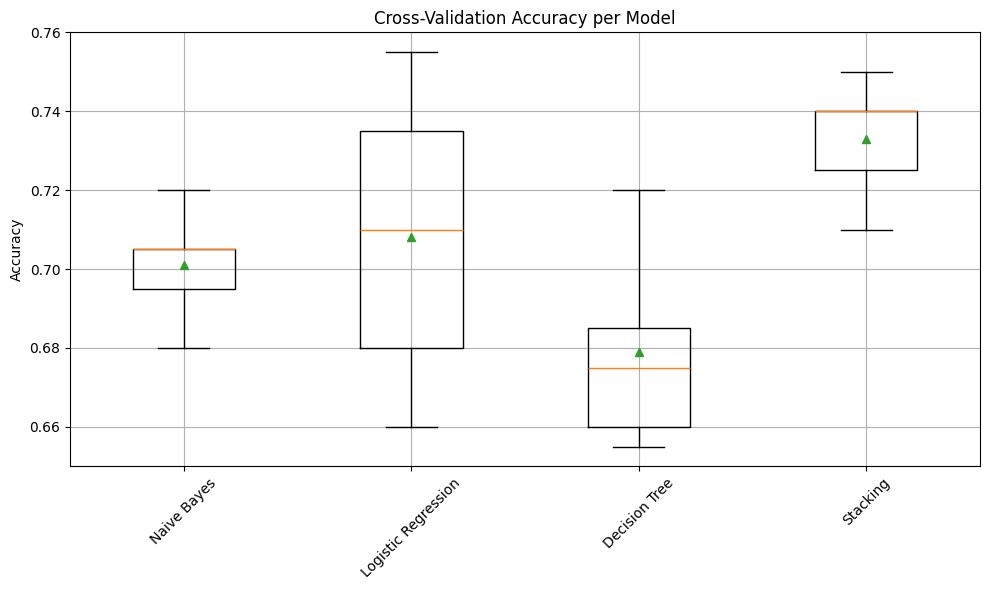

In [6]:
# 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = evaluate_model_cv(name, model, X, y)
    cv_results[name] = scores

stack_scores = evaluate_model_cv("Stacking", stack, X, y)
cv_results["Stacking"] = stack_scores

plt.figure(figsize=(10, 6))
plt.boxplot(cv_results.values(), labels=cv_results.keys(), showmeans=True)
plt.title("Cross-Validation Accuracy per Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()





## 3. Malo detaljnija analiza modela

- predikcije sloja 0
- koeficijenti na ulazu u sloj 1 (Logistic Regression)


In [12]:
import pandas as pd

base_preds = []

for name, model in stack.named_estimators_.items():
    probas = model.predict_proba(X_test)[:, 1]
    base_preds.append(probas)
meta_input = pd.DataFrame(base_preds).T
meta_input.columns = stack.named_estimators_.keys()
meta_input['True Label'] = y_test

# ispis za nekoliko prvih
print(meta_input.head())


   naive_bayes  logistic_regression  decision_tree  True Label
0     0.318278             0.332857       0.705882           1
1     0.936933             0.886717       0.961905           1
2     0.846122             0.938304       0.844444           1
3     0.816715             0.530751       0.416667           1
4     0.106910             0.153243       0.026786           0


            Base Model    Weight
1  logistic_regression  1.810939
0          naive_bayes  1.765862
2        decision_tree  1.153981


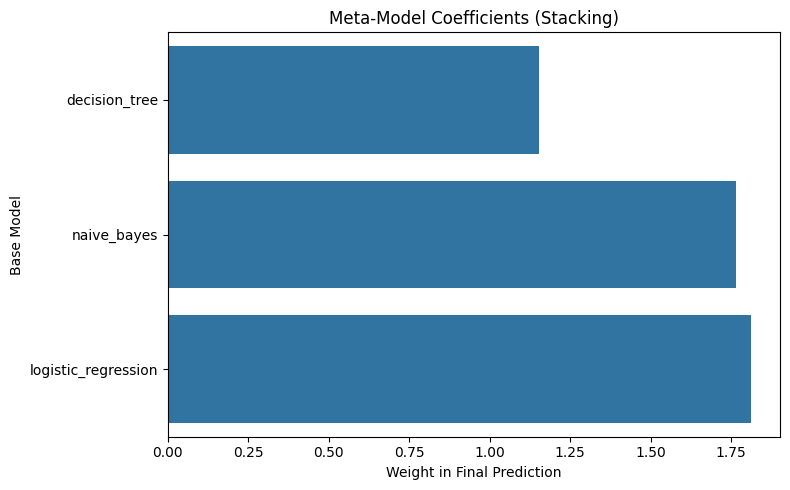

In [13]:
meta_model = stack.final_estimator_
feature_names = list(stack.named_estimators_.keys())
coefs = meta_model.coef_.flatten()

coef_df = pd.DataFrame({'Base Model': feature_names, 'Weight': coefs})
print(coef_df.sort_values(by='Weight', ascending=False))

plt.figure(figsize=(8, 5))
sns.barplot(x='Weight', y='Base Model', data=coef_df.sort_values('Weight', ascending=True))
plt.title("Meta-Model Coefficients (Stacking)")
plt.xlabel("Weight in Final Prediction")
plt.tight_layout()
plt.show()